In [126]:
# Importando as bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

In [127]:
# Importando o dataset
df1 = pd.read_csv("/content/sample_data/3.1-data-sheet-udemy-courses-business-courses.csv")
df2 = pd.read_csv("/content/sample_data/3.1-data-sheet-udemy-courses-design-courses.csv")
df3 = pd.read_csv("/content/sample_data/3.1-data-sheet-udemy-courses-music-courses.csv")
df4 = pd.read_csv("/content/sample_data/3.1-data-sheet-udemy-courses-web-development.csv")

# Unificando os datasets
df = pd.concat([df1, df2, df3, df4], ignore_index=True)

In [128]:
# Visualizar primeiras linhas
df.head()

,course_id,course_title,url,price,num_subscribers,num_reviews,num_lectures,level,Rating,content_duration,published_timestamp,subject
0,49798.0,Bitcoin or How I Learned to Stop Worrying and ...,https://www.udemy.com/bitcoin-or-how-i-learned...,0.0,65576.0,936.0,24.0,All Levels,0.56,8.0,2013-04-20T02:25:22Z,Business Finance
1,48841.0,Accounting in 60 Minutes - A Brief Introduction,https://www.udemy.com/accounting-in-60-minutes...,0.0,56659.0,4397.0,16.0,Beginner Level,0.95,1.5,2013-04-07T21:39:25Z,Business Finance
2,133536.0,Stock Market Investing for Beginners,https://www.udemy.com/the-beginners-guide-to-t...,0.0,50855.0,2698.0,15.0,All Levels,0.91,1.5,2013-12-25T19:53:34Z,Business Finance
3,151668.0,Introduction to Financial Modeling,https://www.udemy.com/financial-modeling-asimp...,0.0,29167.0,1463.0,8.0,All Levels,0.18,1.5,2014-05-27T16:22:16Z,Business Finance
4,648826.0,The Complete Financial Analyst Course 2017,https://www.udemy.com/the-complete-financial-a...,195.0,24481.0,2347.0,174.0,All Levels,0.37,10.0,2016-01-21T01:38:48Z,Business Finance


In [129]:
# Verificar as informações
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3681 entries, 0 to 3680
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   course_id            3676 non-null   float64
 1   course_title         3676 non-null   object 
 2   url                  3676 non-null   object 
 3   price                3676 non-null   float64
 4   num_subscribers      3676 non-null   float64
 5   num_reviews          3676 non-null   float64
 6   num_lectures         3676 non-null   float64
 7   level                3676 non-null   object 
 8   Rating               3677 non-null   float64
 9   content_duration     3676 non-null   float64
 10  published_timestamp  3676 non-null   object 
 11  subject              3677 non-null   object 
dtypes: float64(7), object(5)
memory usage: 345.2+ KB


In [136]:
#Remoção de StopWords

df['course_title'] = df['course_title'].fillna('')

stopwords = set(ENGLISH_STOP_WORDS)

palavras = " ".join(df['course_title']).split()

palavras_filtradas = [
    p for p in palavras
    if p not in stopwords and len(p) > 2
]
# Verificar palavras mais frequentes
frequencia = Counter(palavras_filtradas)

frequencia.most_common(20)

[('learn', 507),
 ('trading', 314),
 ('beginners', 300),
 ('course', 245),
 ('web', 221),
 ('guitar', 220),
 ('design', 203),
 ('piano', 194),
 ('complete', 187),
 ('forex', 172),
 ('build', 172),
 ('photoshop', 172),
 ('create', 162),
 ('play', 159),
 ('javascript', 152),
 ('financial', 144),
 ('wordpress', 138),
 ('website', 131),
 ('beginner', 128),
 ('guide', 127)]

In [131]:
# Padronização do texto
def limpar_texto(texto):
    if isinstance(texto, str):
        texto = texto.lower()
        texto = re.sub(r'[^\w\s]', '', texto)
        return texto
    return ""

df['course_title'] = df['course_title'].apply(limpar_texto)

# Tratamento de valores nulos e duplicados

df = df.dropna()
df = df.drop_duplicates()


In [132]:
df_clean = df.copy()
df_clean.to_csv("udemy_cursos_completos.csv", index=False)

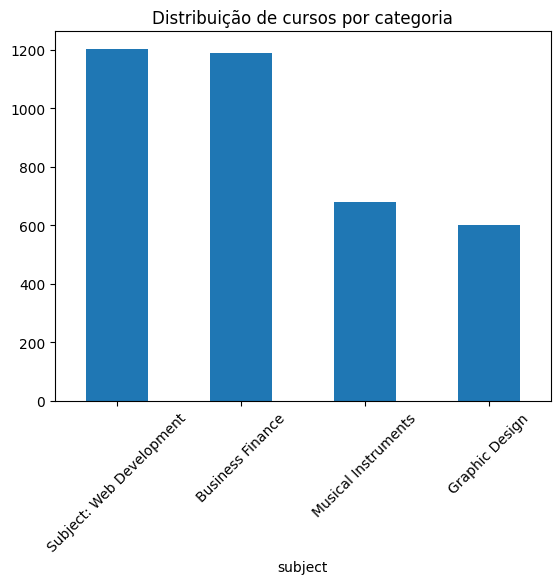

In [133]:
# Gráfico de distribuição de cursos por categoria (Subject)
df['subject'].value_counts().plot(kind='bar')
plt.title("Distribuição de cursos por categoria")
plt.xticks(rotation=45)
plt.show()

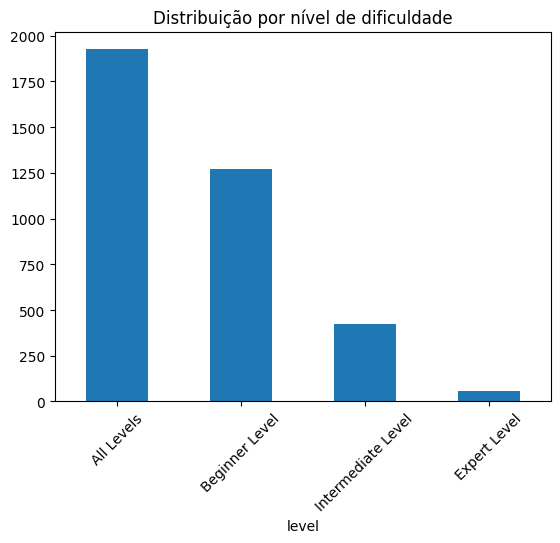

In [134]:
# Gráfico de distribuição de cursos por nível de dificuldade
df['level'].value_counts().plot(kind='bar')
plt.title("Distribuição por nível de dificuldade")
plt.xticks(rotation=45)
plt.show()

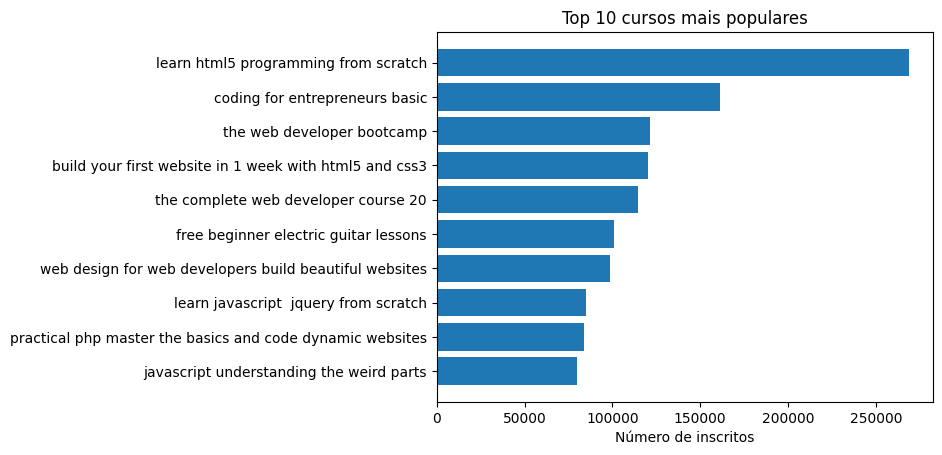

In [135]:
#Gráfico do top 10 cursos mais populares

top10 = df.sort_values(by='num_subscribers', ascending=False).head(10)

plt.figure()
plt.barh(top10['course_title'], top10['num_subscribers'])
plt.xlabel("Número de inscritos")
plt.title("Top 10 cursos mais populares")
plt.gca().invert_yaxis()
plt.show()